In [6]:

# ============================================================
# BƯỚC 1. NẠP DỮ LIỆU VÀ THIẾT LẬP
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.signal import find_peaks

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# ------------------------------------------------------------
# Thiết lập style cho biểu đồ
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# ------------------------------------------------------------
# Đường dẫn dữ liệu
# ------------------------------------------------------------
DATA_PATH =r"feature_for_clustering.csv"
# DATA_PATH = r"C:\Users\Admin\Desktop\TANPHAT\hocotruong\Năm ba 2025-2026\HK2_A\Phantichvatrucquandulieu\DA_cuoimon\data_clustering_final4.csv"

In [7]:

# ------------------------------------------------------------
# Nạp dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(DATA_PATH)
print("=" * 80)
print("THÔNG TIN DỮ LIỆU")
print("=" * 80)
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nHead:")
print(df.head())

# ------------------------------------------------------------
# Dữ liệu clustering: toàn bộ cột số
# ------------------------------------------------------------
X = df.select_dtypes(include=[np.number]).copy()

print("\n" + "=" * 80)
print("MA TRẬN ĐẦU VÀO CHO CLUSTERING")
print("=" * 80)
print(f"Số samples  : {X.shape[0]}")
print(f"Số features : {X.shape[1]}")


THÔNG TIN DỮ LIỆU
Shape: (2845, 24)

Columns:
['FOLLOWERS', 'VIDEO_COUNT', 'VIDEO_COUNT_3M_x', 'VIEW_STD', 'VIEW_CV', 'VIEW_MEAN_V', 'MEAN_LIKES_3M', 'MAX_LIKES_3M', 'MEAN_COMMENTS_3M', 'MAX_COMMENTS_3M', 'MEAN_SHARES_3M', 'MAX_SHARES_3M', 'MEAN_SAVES_3M', 'MAX_SAVES_3M', 'MEAN_VIEWS_RATE_3M', 'MEAN_LIKE_RATE_3M', 'MEAN_COMMENT_RATE_3M', 'MEAN_SHARE_RATE_3M', 'MEAN_SAVE_RATE_3M', 'AVG_POST_GAP', 'POSTING_CONSISTENCY', 'VIDEOS_PER_WEEK', 'MAX_VIRAL_STRENGTH', 'COLLAB_SCORE']

Head:
   FOLLOWERS  VIDEO_COUNT  VIDEO_COUNT_3M_x       VIEW_STD   VIEW_CV  \
0      34700          396              39.0    9020.530159  0.883415   
1     283800         1273             322.0   20107.036653  2.407199   
2     104600         1484             344.0  156538.152516  2.554624   
3     619400         1729              51.0   63516.916866  1.428188   
4      91900          386              41.0   35320.956860  1.901714   

    VIEW_MEAN_V  MEAN_LIKES_3M  MAX_LIKES_3M  MEAN_COMMENTS_3M  \
0  10210.974359

In [16]:
print(df.columns.tolist())


['FOLLOWERS', 'VIDEO_COUNT', 'VIDEO_COUNT_3M_x', 'VIEW_STD', 'VIEW_CV', 'VIEW_MEAN_V', 'MEAN_LIKES_3M', 'MAX_LIKES_3M', 'MEAN_COMMENTS_3M', 'MAX_COMMENTS_3M', 'MEAN_SHARES_3M', 'MAX_SHARES_3M', 'MEAN_SAVES_3M', 'MAX_SAVES_3M', 'MEAN_VIEWS_RATE_3M', 'MEAN_LIKE_RATE_3M', 'MEAN_COMMENT_RATE_3M', 'MEAN_SHARE_RATE_3M', 'MEAN_SAVE_RATE_3M', 'AVG_POST_GAP', 'POSTING_CONSISTENCY', 'VIDEOS_PER_WEEK', 'MAX_VIRAL_STRENGTH', 'COLLAB_SCORE']


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   FOLLOWERS             2845 non-null   int64  
 1   VIDEO_COUNT           2845 non-null   int64  
 2   VIDEO_COUNT_3M_x      2845 non-null   float64
 3   VIEW_STD              2845 non-null   float64
 4   VIEW_CV               2845 non-null   float64
 5   VIEW_MEAN_V           2845 non-null   float64
 6   MEAN_LIKES_3M         2845 non-null   float64
 7   MAX_LIKES_3M          2845 non-null   float64
 8   MEAN_COMMENTS_3M      2845 non-null   float64
 9   MAX_COMMENTS_3M       2845 non-null   float64
 10  MEAN_SHARES_3M        2845 non-null   float64
 11  MAX_SHARES_3M         2845 non-null   float64
 12  MEAN_SAVES_3M         2845 non-null   float64
 13  MAX_SAVES_3M          2845 non-null   float64
 14  MEAN_VIEWS_RATE_3M    2845 non-null   float64
 15  MEAN_LIKE_RATE_3M    

In [11]:
df.duplicated().sum()

0

In [257]:
# df = df[ 
#          ['FOLLOWERS', 'VIDEO_COUNT_3M_x','VIEW_MEAN_V', 'VIEW_STD', 'VIEW_CV', 'VIEW_P90', 
#               'MEAN_LIKES_3M', 'P90_LIKES_3M', 'MAX_LIKES_3M', 
#          ]]


In [258]:
# df = df[ 
#          [ 'FOLLOWERS','VIDEO_COUNT_3M_x', 'VIEW_STD', 'VIEW_CV', 'VIEW_MEAN', 'VIEW_P90',
#           'MEAN_COMMENTS_3M', 'P90_COMMENTS_3M', 'MAX_COMMENTS_3M',
#          ]]

In [259]:
# df = df[ 
#          ['FOLLOWERS', 'VIDEO_COUNT_3M_x', 'VIEW_STD', 'VIEW_CV', 'VIEW_MEDIAN', 'VIEW_P90',
#           'MEDIAN_SHARES_3M', 'P90_SHARES_3M', 'MAX_SHARES_3M', 
#          ]]

In [260]:
# df = df[ 
#          ['FOLLOWERS', 'VIDEO_COUNT_3M_x', 'VIEW_STD', 'VIEW_CV', 'VIEW_MEDIAN', 'VIEW_P90',
#           'MEDIAN_SAVES_3M', 'P90_SAVES_3M', 'MAX_SAVES_3M',  
#          ]]


In [261]:
# df = df[ 
#          ['VIEW_STD','VIEW_P90',
#           'POSTING_CONSISTENCY'
#          ]]

In [262]:
# df = df[ 
#          ['VIEW_STD','VIEW_P90',
#          'VIRAL_MAGNITUDE'
#          ]]

In [18]:
df.dropna(inplace=True)

In [19]:
print(df.shape)
print(df.columns.tolist())
df.describe(percentiles=[0.5, 0.9, 0.99]).T

(2805, 24)
['FOLLOWERS', 'VIDEO_COUNT', 'VIDEO_COUNT_3M_x', 'VIEW_STD', 'VIEW_CV', 'VIEW_MEAN_V', 'MEAN_LIKES_3M', 'MAX_LIKES_3M', 'MEAN_COMMENTS_3M', 'MAX_COMMENTS_3M', 'MEAN_SHARES_3M', 'MAX_SHARES_3M', 'MEAN_SAVES_3M', 'MAX_SAVES_3M', 'MEAN_VIEWS_RATE_3M', 'MEAN_LIKE_RATE_3M', 'MEAN_COMMENT_RATE_3M', 'MEAN_SHARE_RATE_3M', 'MEAN_SAVE_RATE_3M', 'AVG_POST_GAP', 'POSTING_CONSISTENCY', 'VIDEOS_PER_WEEK', 'MAX_VIRAL_STRENGTH', 'COLLAB_SCORE']


,count,mean,std,min,50%,90%,99%,max
FOLLOWERS,2805.0,436356.317647,1.132163e+06,5571.000000,152000.000000,9.327200e+05,4.876000e+06,2.120000e+07
VIDEO_COUNT,2805.0,725.837077,1.403444e+03,1.000000,379.000000,1.493000e+03,6.171120e+03,3.590000e+04
VIDEO_COUNT_3M_x,2805.0,72.613547,9.767296e+01,1.000000,39.000000,1.750000e+02,5.140000e+02,5.600000e+02
VIEW_STD,2805.0,429051.221740,8.434465e+05,0.000000,172165.223799,1.005592e+06,3.708196e+06,1.411421e+07
VIEW_CV,2805.0,1.908519,1.236025e+00,0.000000,1.649794,3.382743e+00,6.344815e+00,1.484748e+01
VIEW_MEAN_V,2805.0,242043.630998,6.053454e+05,205.741379,101758.421875,5.723149e+05,1.990217e+06,2.037500e+07
MEAN_LIKES_3M,2805.0,9256.451692,2.374579e+04,1.500000,3213.136364,2.162930e+04,8.647049e+04,8.419000e+05
MAX_LIKES_3M,2805.0,87896.967914,1.854319e+05,8.000000,30600.000000,2.170200e+05,7.824360e+05,3.600000e+06
MEAN_COMMENTS_3M,2805.0,117.478624,4.004532e+02,0.000000,45.430769,2.473817e+02,1.041538e+03,1.538183e+04
MAX_COMMENTS_3M,2805.0,1483.260250,1.005829e+04,0.000000,328.000000,2.998800e+03,1.518000e+04,4.851000e+05


In [20]:
from sklearn.preprocessing import RobustScaler , StandardScaler,MinMaxScaler
sceler = MinMaxScaler()
scaled_features = sceler.fit_transform(df)
df = pd.DataFrame(scaled_features, columns=df.columns)     

In [21]:
print(df.shape)
print(df.columns.tolist())
df.describe(percentiles=[0.5, 0.9, 0.99]).T

(2805, 24)
['FOLLOWERS', 'VIDEO_COUNT', 'VIDEO_COUNT_3M_x', 'VIEW_STD', 'VIEW_CV', 'VIEW_MEAN_V', 'MEAN_LIKES_3M', 'MAX_LIKES_3M', 'MEAN_COMMENTS_3M', 'MAX_COMMENTS_3M', 'MEAN_SHARES_3M', 'MAX_SHARES_3M', 'MEAN_SAVES_3M', 'MAX_SAVES_3M', 'MEAN_VIEWS_RATE_3M', 'MEAN_LIKE_RATE_3M', 'MEAN_COMMENT_RATE_3M', 'MEAN_SHARE_RATE_3M', 'MEAN_SAVE_RATE_3M', 'AVG_POST_GAP', 'POSTING_CONSISTENCY', 'VIDEOS_PER_WEEK', 'MAX_VIRAL_STRENGTH', 'COLLAB_SCORE']


,count,mean,std,min,50%,90%,99%,max
FOLLOWERS,2805.0,0.020325,0.053418,0.0,0.006909,0.043745,0.229798,1.0
VIDEO_COUNT,2805.0,0.020191,0.039094,0.0,0.010530,0.041561,0.171874,1.0
VIDEO_COUNT_3M_x,2805.0,0.128110,0.174728,0.0,0.067979,0.311270,0.917710,1.0
VIEW_STD,2805.0,0.030399,0.059759,0.0,0.012198,0.071247,0.262728,1.0
VIEW_CV,2805.0,0.128542,0.083248,0.0,0.111116,0.227833,0.427333,1.0
VIEW_MEAN_V,2805.0,0.011869,0.029711,0.0,0.004984,0.028079,0.097670,1.0
MEAN_LIKES_3M,2805.0,0.010993,0.028205,0.0,0.003815,0.025689,0.102707,1.0
MAX_LIKES_3M,2805.0,0.024414,0.051509,0.0,0.008498,0.060281,0.217342,1.0
MEAN_COMMENTS_3M,2805.0,0.007637,0.026034,0.0,0.002954,0.016083,0.067712,1.0
MAX_COMMENTS_3M,2805.0,0.003058,0.020734,0.0,0.000676,0.006182,0.031293,1.0


In [268]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# X_pca = PCA(n_components=0.95, random_state=42).fit_transform(df)

# plt.scatter(X_pca[:,0], X_pca[:,1], s=5)
# plt.title("PCA projection")
# plt.show()

In [23]:
pca_full = PCA(n_components=0.95, random_state=42) 
df_ = pca_full.fit_transform(df)

In [270]:
# df_ = df 

<Axes: >

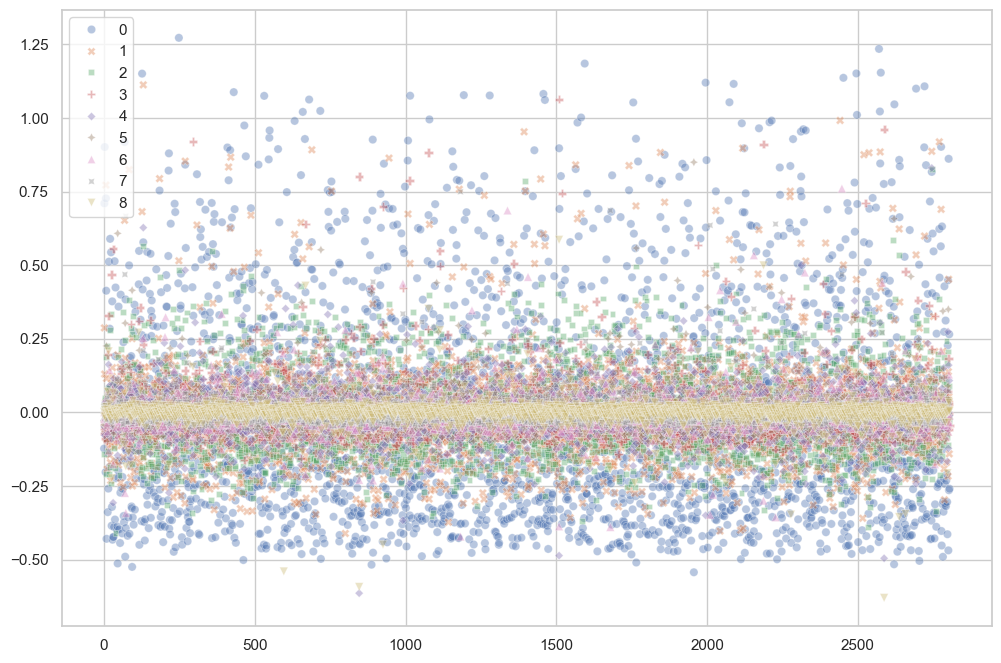

In [24]:

df_scatter = df_.copy()
# 3. Trực quan hóa bằng Scatter Plot
plt.figure(figsize=(12, 8))

# Dùng Seaborn để vẽ biểu đồ có độ phân tán
# alpha=0.5: làm mờ các điểm để nhìn thấy các vùng bị đè lên nhau (Mật độ)
sns.scatterplot(
    data=df_scatter,  
    alpha=0.4, 
    edgecolor='w'
)

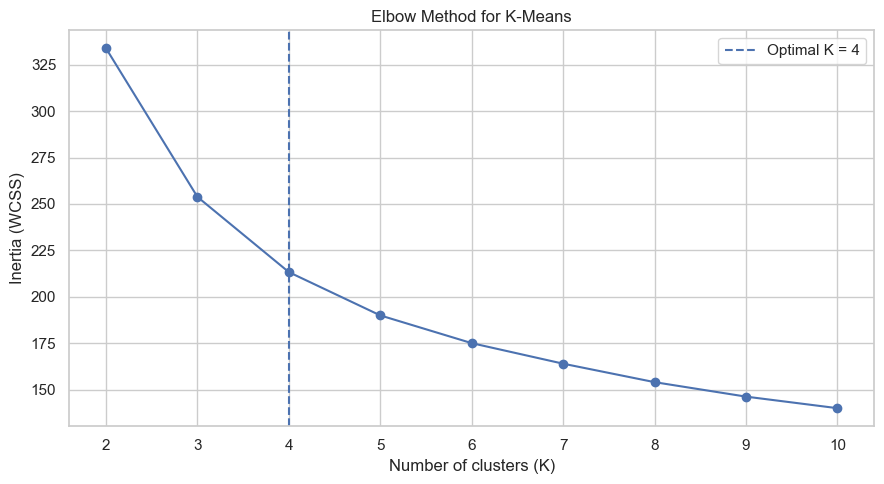


K-Means optimal K: 3
K-Means cluster counts: Counter({1: 1902, 0: 903})


In [25]:

# ============================================================
# BƯỚC 2. TRIỂN KHAI CÁC THUẬT TOÁN PHÂN CỤM
# ============================================================

# ------------------------------------------------------------
# 2.1. K-MEANS: Elbow Method + huấn luyện mô hình
# ------------------------------------------------------------
def find_optimal_k_elbow(X, k_range=range(2, 11), plot=True):
    """
    Tính inertia cho từng K và chọn K tối ưu bằng Elbow Method.
    Ở đây dùng 'distance to line' để xác định điểm khuỷu một cách tự động.

    Parameters
    ----------
    X : array-like
        Ma trận đặc trưng
    k_range : iterable
        Dải giá trị K thử nghiệm
    plot : bool
        Có vẽ biểu đồ Elbow hay không

    Returns
    -------
    optimal_k : int
        Số cụm K tối ưu
    inertias : list
        Danh sách inertia theo từng K
    """
    ks = list(k_range)
    inertias = []

    for k in ks:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        model.fit(X)
        inertias.append(model.inertia_)

    # --- tự động tìm elbow bằng khoảng cách từ điểm tới đường nối đầu-cuối ---
    p1 = np.array([ks[0], inertias[0]])
    p2 = np.array([ks[-1], inertias[-1]])

    distances = []
    for k, inertia in zip(ks, inertias):
        p = np.array([k, inertia])
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(dist)

    optimal_k = ks[int(np.argmax(distances))]

    if plot:
        plt.figure(figsize=(9, 5))
        plt.plot(ks, inertias, marker="o")
        plt.axvline(optimal_k, linestyle="--", label=f"Optimal K = {optimal_k}")
        plt.title("Elbow Method for K-Means")
        plt.xlabel("Number of clusters (K)")
        plt.ylabel("Inertia (WCSS)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return optimal_k, inertias


optimal_k_kmeans, inertias = find_optimal_k_elbow(df, k_range=range(2, 11), plot=True)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(df_)

print("\nK-Means optimal K:", 3)
print("K-Means cluster counts:", Counter(kmeans_labels))




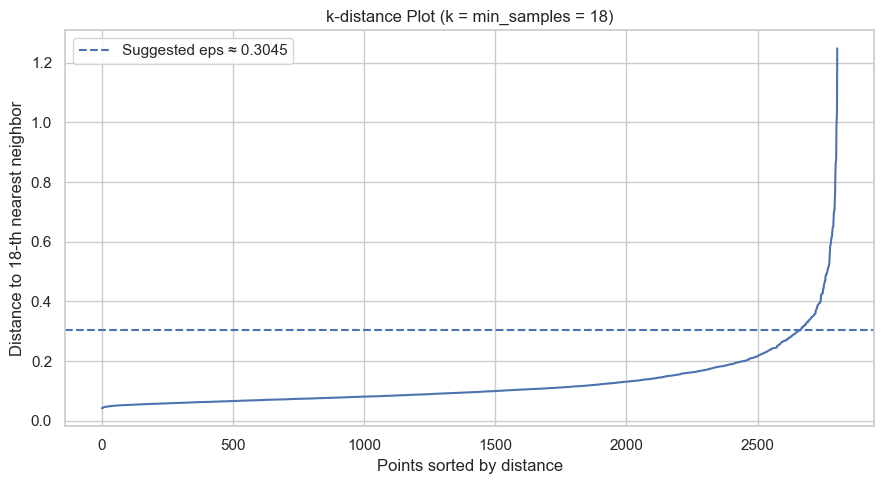


DBSCAN suggested eps       : 0.3045
DBSCAN suggested min_samples: 18
DBSCAN labels counts: Counter({0: 2805})
DBSCAN noise points: 0


In [26]:

# ------------------------------------------------------------
# 2.2. DBSCAN: tìm eps bằng k-distance plot
# ------------------------------------------------------------
def suggest_dbscan_params(X, min_samples=None, percentile=95, plot=True):
    """
    Gợi ý tham số DBSCAN bằng k-distance plot.

    Ý tưởng:
    - Chọn min_samples mặc định = 2 * số chiều, nhưng tối thiểu là 5
    - Tính khoảng cách tới láng giềng thứ k = min_samples
    - Sắp xếp các khoảng cách
    - Gợi ý eps bằng percentile cao (ví dụ 95%)

    Parameters
    ----------
    X : array-like
    min_samples : int or None
    percentile : int
    plot : bool

    Returns
    -------
    eps_suggested : float
    min_samples : int
    k_distances_sorted : np.ndarray
    """
    n_features = X.shape[1]

    if min_samples is None:
        min_samples = max(5, 2 * n_features)

    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X)

    distances, _ = nn.kneighbors(X)
    # lấy khoảng cách tới láng giềng thứ k
    k_distances = distances[:, -1]
    k_distances_sorted = np.sort(k_distances)

    eps_suggested = np.percentile(k_distances_sorted, percentile)

    if plot:
        plt.figure(figsize=(9, 5))
        plt.plot(k_distances_sorted)
        plt.axhline(eps_suggested, linestyle="--",
                    label=f"Suggested eps ≈ {eps_suggested:.4f}")
        plt.title(f"k-distance Plot (k = min_samples = {min_samples})")
        plt.xlabel("Points sorted by distance")
        plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return eps_suggested, min_samples, k_distances_sorted


eps_suggested, min_samples_suggested, kdist = suggest_dbscan_params(
    df_,
    min_samples=None,
    percentile=95,
    plot=True
)

dbscan = DBSCAN(eps=2.0, min_samples=30)
dbscan_labels = dbscan.fit_predict(df_)

print("\nDBSCAN suggested eps       :", round(eps_suggested, 4))
print("DBSCAN suggested min_samples:", min_samples_suggested)
print("DBSCAN labels counts:", Counter(dbscan_labels))
print("DBSCAN noise points:", np.sum(dbscan_labels == -1))



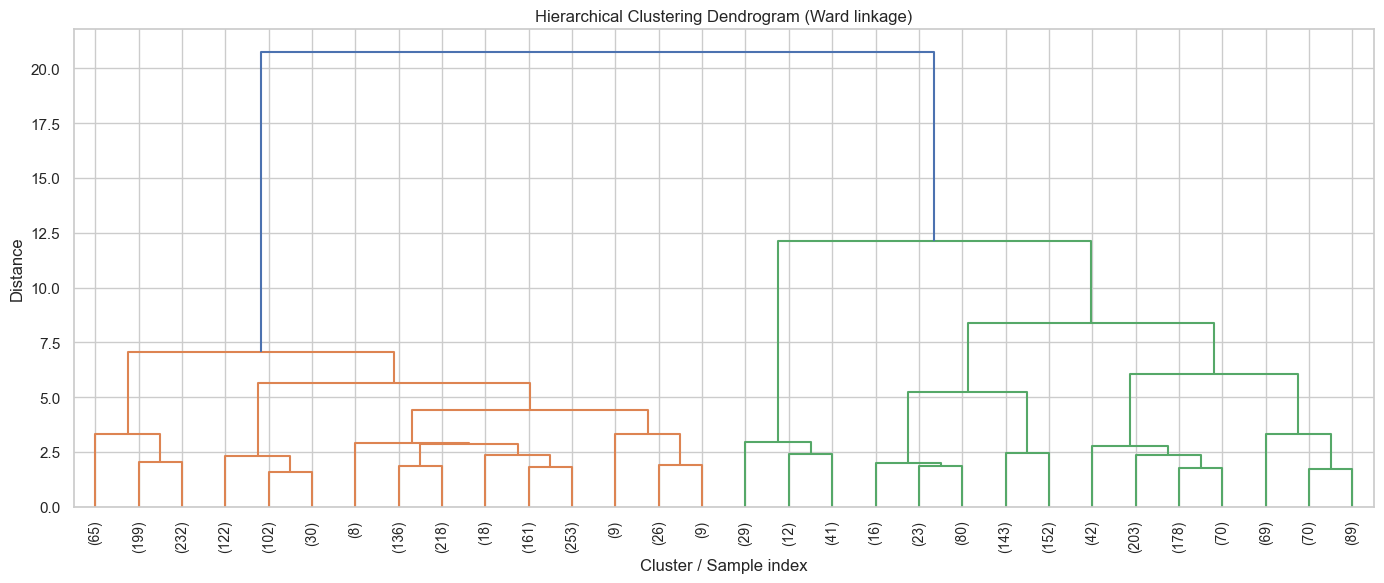


Hierarchical suggested K: 2
Hierarchical cluster counts: Counter({1: 1588, 0: 1217})


In [27]:

# ------------------------------------------------------------
# 2.3. HIERARCHICAL CLUSTERING: Dendrogram + huấn luyện
# ------------------------------------------------------------
def plot_dendrogram_and_choose_k(X, truncate_mode="lastp", p=30):
    """
    Vẽ dendrogram để người dùng quan sát trực quan.
    Đồng thời gợi ý số cụm bằng cách xét các khoảng nhảy lớn trong linkage distance.

    Returns
    -------
    Z : linkage matrix
    suggested_k : int
    """
    Z = linkage(X, method="ward")

    plt.figure(figsize=(14, 6))
    dendrogram(Z, truncate_mode=truncate_mode, p=p, leaf_rotation=90, leaf_font_size=10)
    plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
    plt.xlabel("Cluster / Sample index")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

    # heuristic: tìm khoảng nhảy lớn trong các khoảng cách hợp nhất cuối
    merge_distances = Z[:, 2]
    last_distances = merge_distances[-10:] if len(merge_distances) >= 10 else merge_distances
    diffs = np.diff(last_distances)

    if len(diffs) > 0:
        jump_idx = np.argmax(diffs)
        # số cụm xấp xỉ: số merge cuối còn lại trước cú nhảy
        suggested_k = max(2, len(last_distances) - jump_idx)
    else:
        suggested_k = 3

    return Z, suggested_k


Z, suggested_k_hier = plot_dendrogram_and_choose_k(df_, truncate_mode="lastp", p=30)

agglomerative = AgglomerativeClustering(n_clusters=2, linkage="ward")
hier_labels = agglomerative.fit_predict(df_)

print("\nHierarchical suggested K:", suggested_k_hier)
print("Hierarchical cluster counts:", Counter(hier_labels))



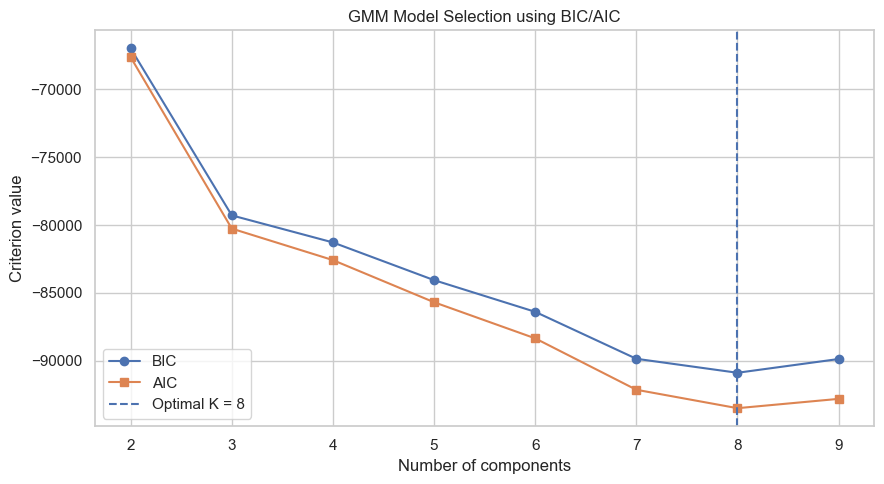


GMM optimal K: 8
GMM cluster counts: Counter({2: 578, 6: 491, 3: 415, 5: 352, 7: 345, 1: 333, 0: 167, 4: 124})


In [28]:

# ------------------------------------------------------------
# 2.4. GMM: soft clustering
# ------------------------------------------------------------
def find_optimal_k_gmm_bic(X, k_range=range(2, 11), plot=True):
    """
    Chọn số cụm cho GMM bằng BIC: càng thấp càng tốt.
    """
    ks = list(k_range)
    bics = []
    aics = []

    for k in ks:
        gmm = GaussianMixture(n_components=k, random_state=42, covariance_type="full")
        gmm.fit(X)
        bics.append(gmm.bic(X))
        aics.append(gmm.aic(X))

    optimal_k = ks[int(np.argmin(bics))]

    if plot:
        plt.figure(figsize=(9, 5))
        plt.plot(ks, bics, marker="o", label="BIC")
        plt.plot(ks, aics, marker="s", label="AIC")
        plt.axvline(optimal_k, linestyle="--", label=f"Optimal K = {optimal_k}")
        plt.title("GMM Model Selection using BIC/AIC")
        plt.xlabel("Number of components")
        plt.ylabel("Criterion value")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return optimal_k, bics, aics


optimal_k_gmm, bics, aics = find_optimal_k_gmm_bic(df_, k_range=range(2, 10), plot=True)

gmm = GaussianMixture(n_components=optimal_k_gmm, random_state=42, covariance_type="full")
gmm_labels = gmm.fit_predict(df_)
gmm_probs = gmm.predict_proba(df_)

print("\nGMM optimal K:", optimal_k_gmm)
print("GMM cluster counts:", Counter(gmm_labels))


In [29]:

# ============================================================
# BƯỚC 3. ĐÁNH GIÁ MÔ HÌNH
# ============================================================

def evaluate_clustering(X, labels, model_name):
    """
    Tính 3 chỉ số đánh giá cụm:
    - Silhouette Score: càng cao càng tốt
    - Davies-Bouldin Index: càng thấp càng tốt
    - Calinski-Harabasz Index: càng cao càng tốt

    Lưu ý:
    - DBSCAN có thể tạo noise label = -1
    - Nếu tất cả điểm thuộc cùng một cụm, metrics không còn ý nghĩa
    """
    unique_labels = set(labels)

    # Số cụm thực, không tính noise (-1)
    n_clusters = len(unique_labels - {-1})
    n_noise = np.sum(np.array(labels) == -1)

    # Nếu cụm hợp lệ < 2 thì không tính được metrics
    if n_clusters < 2:
        return {
            "Algorithm": model_name,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan
        }

    # Với DBSCAN, để đánh giá "chất lượng cụm lõi", thường loại noise khỏi metric
    if -1 in unique_labels:
        mask = np.array(labels) != -1
        X_eval = X[mask]
        labels_eval = np.array(labels)[mask]
    else:
        X_eval = X
        labels_eval = labels

    # Nếu sau khi bỏ noise mà vẫn < 2 cụm thì trả NaN
    if len(set(labels_eval)) < 2:
        return {
            "Algorithm": model_name,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan
        }

    sil = silhouette_score(X_eval, labels_eval)
    dbi = davies_bouldin_score(X_eval, labels_eval)
    chi = calinski_harabasz_score(X_eval, labels_eval)

    return {
        "Algorithm": model_name,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "Silhouette": sil,
        "Davies_Bouldin": dbi,
        "Calinski_Harabasz": chi
    }

results = []
results.append(evaluate_clustering(df, kmeans_labels, "K-Means"))
results.append(evaluate_clustering(df, dbscan_labels, "DBSCAN"))
results.append(evaluate_clustering(df, hier_labels, "Hierarchical (Ward)"))
results.append(evaluate_clustering(df, gmm_labels, "GMM"))

results_df = pd.DataFrame(results)


print("\n" + "=" * 80)
print("BẢNG SO SÁNH KẾT QUẢ")
print("=" * 80)
print(results_df)



BẢNG SO SÁNH KẾT QUẢ
             Algorithm  n_clusters  n_noise  Silhouette  Davies_Bouldin  \
0              K-Means           2        0    0.426061        1.017503   
1               DBSCAN           1        0         NaN             NaN   
2  Hierarchical (Ward)           2        0    0.370301        1.079723   
3                  GMM           8        0    0.012233        3.294451   

   Calinski_Harabasz  
0        1955.912854  
1                NaN  
2        1714.636743  
3         407.557103  


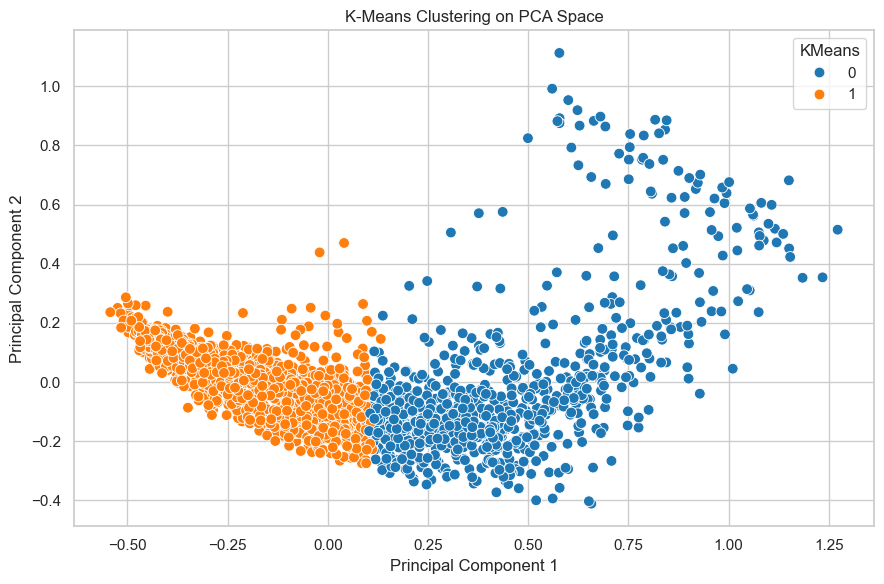

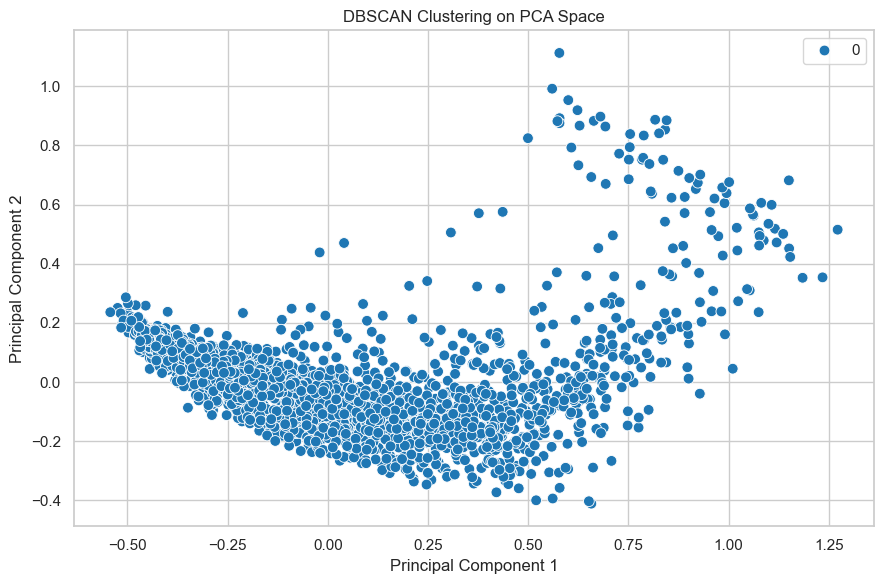

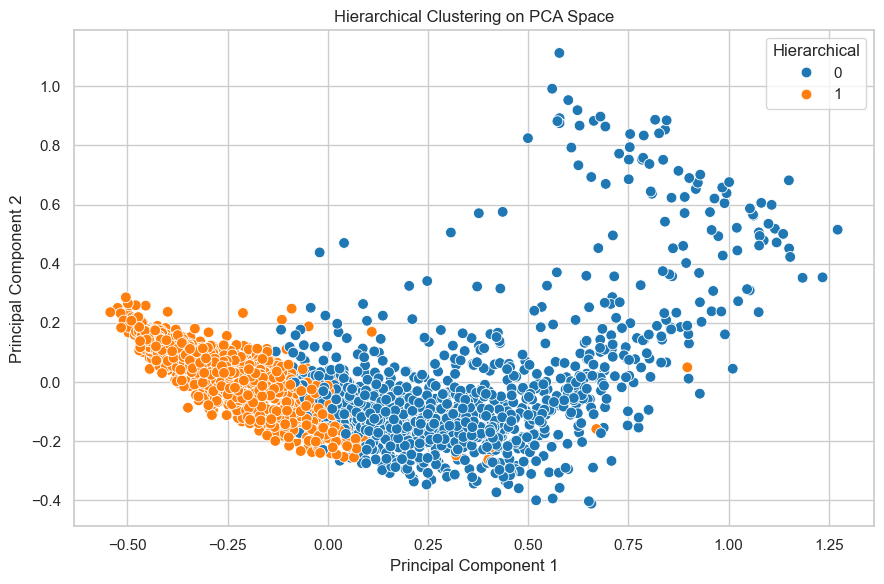

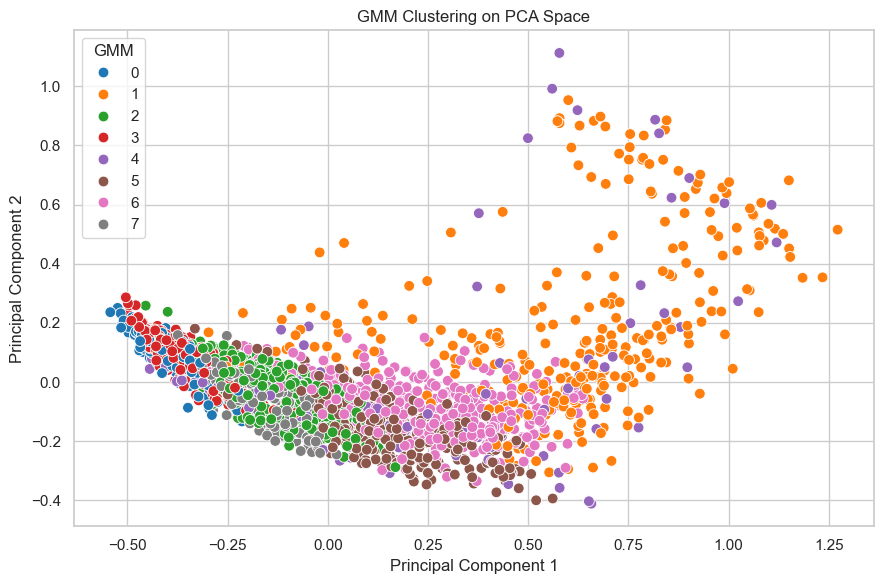

In [32]:

# ============================================================
# BƯỚC 4. TRỰC QUAN HÓA KẾT QUẢ
# ============================================================

# ------------------------------------------------------------
# 4.1. PCA cho trực quan hóa cụm
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "KMeans": kmeans_labels,
    "DBSCAN": dbscan_labels,
    "Hierarchical": hier_labels,
    "GMM": gmm_labels
})

# print("\nExplained variance ratio by PCA:", pca.explained_variance_ratio_)


def plot_cluster_scatter(pca_df, label_col, title, is_dbscan=False):
    """
    Vẽ scatter plot 2D theo PCA cho từng thuật toán.

    Riêng DBSCAN:
    - noise (-1) được làm nổi bật bằng màu xám và marker X
    """
    plt.figure(figsize=(9, 6))

    if is_dbscan:
        clustered = pca_df[pca_df[label_col] != -1]
        noise = pca_df[pca_df[label_col] == -1]

        if len(clustered) > 0:
            sns.scatterplot(
                data=clustered, x="PC1", y="PC2",
                hue=label_col, palette="tab10", s=60
            )

        if len(noise) > 0:
            plt.scatter(
                noise["PC1"], noise["PC2"],
                c="gray", marker="x", s=80, label="Noise"
            )
        plt.legend()
    else:
        sns.scatterplot(
            data=pca_df, x="PC1", y="PC2",
            hue=label_col, palette="tab10", s=60
        )

    plt.title(title)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    plt.show()


plot_cluster_scatter(pca_df, "KMeans", "K-Means Clustering on PCA Space")
plot_cluster_scatter(pca_df, "DBSCAN", "DBSCAN Clustering on PCA Space", is_dbscan=True)
plot_cluster_scatter(pca_df, "Hierarchical", "Hierarchical Clustering on PCA Space")
plot_cluster_scatter(pca_df, "GMM", "GMM Clustering on PCA Space")



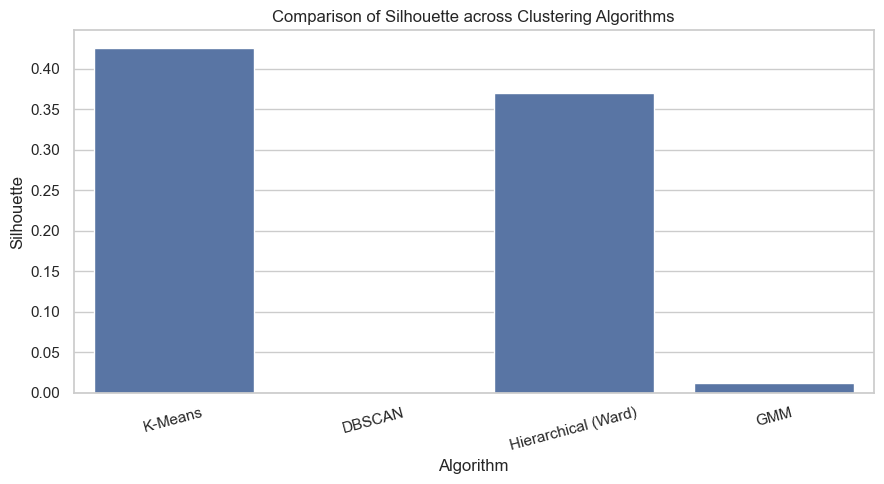

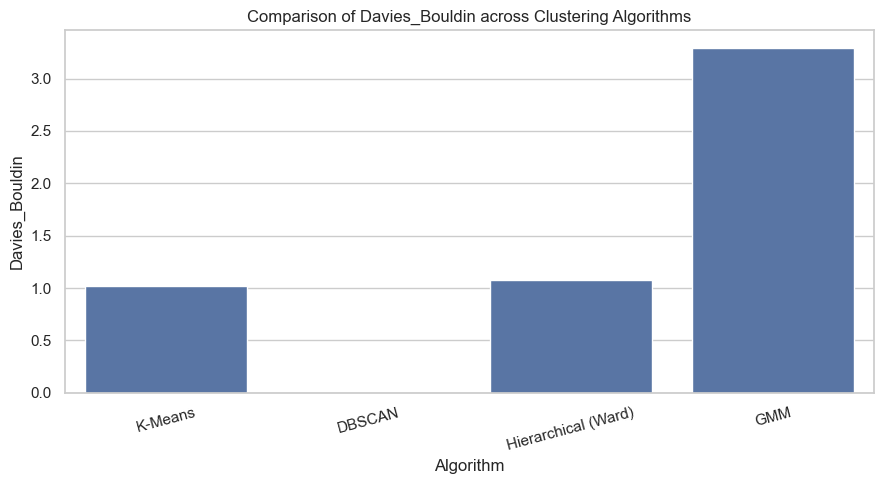

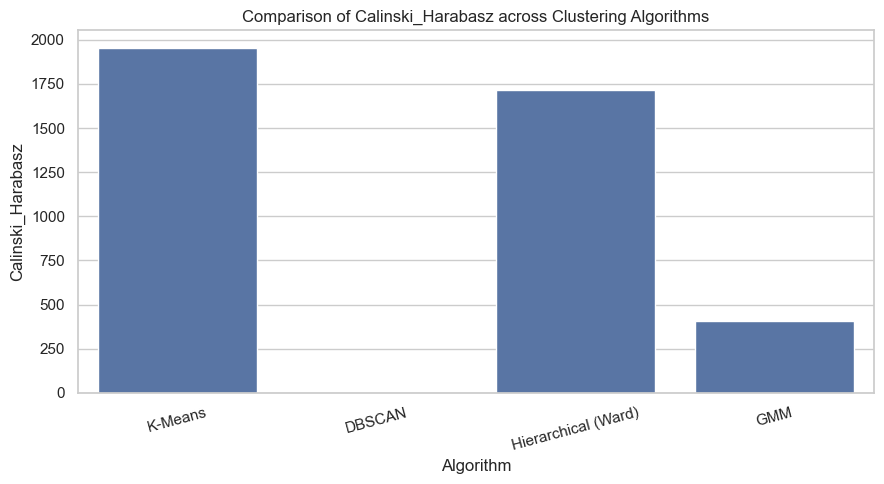

In [31]:

# ------------------------------------------------------------
# 4.2. Biểu đồ cột so sánh các metric
# ------------------------------------------------------------
metrics_to_plot = ["Silhouette", "Davies_Bouldin", "Calinski_Harabasz"]

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 5))
    sns.barplot(data=results_df, x="Algorithm", y=metric)
    plt.title(f"Comparison of {metric} across Clustering Algorithms")
    plt.xlabel("Algorithm")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()



In [279]:

# ============================================================
# PHẦN KẾT LUẬN NHANH
# ============================================================

print("\n" + "=" * 80)
print("KẾT LUẬN GỢI Ý")
print("=" * 80)

# Thuật toán tốt nhất theo từng chỉ số
best_sil = results_df.loc[results_df["Silhouette"].idxmax(), "Algorithm"] if results_df["Silhouette"].notna().any() else None
best_dbi = results_df.loc[results_df["Davies_Bouldin"].idxmin(), "Algorithm"] if results_df["Davies_Bouldin"].notna().any() else None
best_chi = results_df.loc[results_df["Calinski_Harabasz"].idxmax(), "Algorithm"] if results_df["Calinski_Harabasz"].notna().any() else None

print(f"Best by Silhouette Score       : {best_sil}")
print(f"Best by Davies-Bouldin Index   : {best_dbi}")
print(f"Best by Calinski-Harabasz Index: {best_chi}")

print("\nBảng kết quả cuối:")
print(results_df.sort_values(by="Silhouette", ascending=False))

# ------------------------------------------------------------
# Lưu kết quả nếu cần
# ------------------------------------------------------------
# results_df.to_csv("clustering_comparison_results.csv", index=False)
# pca_df.to_csv("clustering_pca_labels.csv", index=False)

print("\nĐã lưu:")
print("- clustering_comparison_results.csv")
print("- clustering_pca_labels.csv")


KẾT LUẬN GỢI Ý
Best by Silhouette Score       : K-Means
Best by Davies-Bouldin Index   : K-Means
Best by Calinski-Harabasz Index: K-Means

Bảng kết quả cuối:
             Algorithm  n_clusters  n_noise  Silhouette  Davies_Bouldin  \
0              K-Means           2        0    0.417531        1.036618   
2  Hierarchical (Ward)           2        0    0.406100        1.062577   
3                  GMM           9        0    0.006061        3.048619   
1               DBSCAN           1        0         NaN             NaN   

   Calinski_Harabasz  
0        1873.399686  
2        1774.645614  
3         363.424049  
1                NaN  

Đã lưu:
- clustering_comparison_results.csv
- clustering_pca_labels.csv
